# 📊 Análise de Dados com Persistência em SQLite - Portal Nexus News

Este notebook demonstra o ciclo completo de dados:
1. **Extração (Scrapping)**: Coleta de dados do arquivo HTML.
2. **Carga (Persistence)**: Armazenamento dos dados em um banco de dados **SQLite**.
3. **Análise (Analytics)**: Consulta ao banco e geração de gráficos estatísticos.

---

## 1. Importação das Bibliotecas

Utilizaremos `sqlite3` para a comunicação com o banco de dados.

In [22]:
import os
import sqlite3
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para os gráficos
sns.set_theme(style="whitegrid")
print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 2. Extração e Persistência no SQLite

Nesta etapa, extraímos os dados e os salvamos no banco de dados local chamado `portal_noticias.db`.

In [23]:
def extrair_e_salvar_no_banco(caminho_html, caminho_db):
    # 1. Extração via BeautifulSoup
    with open(caminho_html, 'r', encoding='utf-8') as f:
        content = f.read()
    
    soup = BeautifulSoup(content, 'html.parser')
    noticias = soup.find_all('article', class_='noticia')
    
    dados_noticias = []
    for item in noticias:
        titulo = item.find(class_='titulo').get_text(strip=True) if item.find(class_='titulo') else "N/A"
        resumo = item.find(class_='resumo').get_text(strip=True) if item.find(class_='resumo') else "N/A"
        categoria = item.find(class_='categoria').get_text(strip=True) if item.find(class_='categoria') else "Geral"
        link = item.find('a', class_='link')['href'] if item.find('a', class_='link') else "#"
        
        dados_noticias.append((titulo, resumo, categoria, link))

    # 2. Conexão com SQLite e Criação da Tabela
    conn = sqlite3.connect(caminho_db)
    cursor = conn.cursor()
    
    # Criar tabela (limpando a anterior se existir para evitar duplicatas no teste)
    cursor.execute("DROP TABLE IF EXISTS noticias")
    cursor.execute('''
        CREATE TABLE noticias (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            titulo TEXT,
            resumo TEXT,
            categoria TEXT,
            link TEXT
        )
    ''')
    
    # Inserção dos dados
    cursor.executemany('''
        INSERT INTO noticias (titulo, resumo, categoria, link) 
        VALUES (?, ?, ?, ?)
    ''', dados_noticias)
    
    conn.commit()
    conn.close()
    print(f"✅ {len(dados_noticias)} notícias salvas no banco de dados '{caminho_db}'.")

# Executar a função
extrair_e_salvar_no_banco("../index.html", "db/portal_noticias.db")

✅ 12 notícias salvas no banco de dados 'db/portal_noticias.db'.


## 3. Leitura do Banco de Dados para Análise

Agora, em vez de usar a lista original, vamos **consultar o banco de dados** usando SQL para carregar um DataFrame do Pandas.

In [24]:
# Conectar ao banco
conn = sqlite3.connect("db/portal_noticias.db")

# Consulta SQL para puxar os dados
query = "SELECT * FROM noticias"

# Carregar diretamente no Pandas
df = pd.read_sql_query(query, conn)

# Criar coluna de tamanho do título para análises posteriores
df['tamanho_titulo'] = df['titulo'].apply(len)

# Fechar conexão
conn.close()

print("✅ Dados carregados do SQLite para o Pandas.")
df.head()

✅ Dados carregados do SQLite para o Pandas.


,id,titulo,resumo,categoria,link,tamanho_titulo
0,1,IA cresce no Brasil,Avanços importantes na inteligência artificial...,Tecnologia,noticia1.html,19
1,2,Python domina mercado,Empresas adotam Python pela sua versatilidade ...,Negócios,noticia2.html,21
2,3,O Futuro do Trabalho Híbrido,Estudos indicam que o modelo híbrido se consol...,Carreira,noticia3.html,28
3,4,Energia Solar em Alta,Investimentos em painéis fotovoltaicos crescem...,Sustentabilidade,noticia4.html,21
4,5,Novo Telescópio Espacial,A agência espacial revela as primeiras imagens...,Ciência,noticia5.html,24


## 4. Visualização dos Dados (Análise)

Com os dados vindos do SQLite, geramos diversos insights visuais para entender o perfil do portal.

C:\Users\luizz\AppData\Local\Temp\ipykernel_14056\1068573149.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")
C:\Users\luizz\AppData\Local\Temp\ipykernel_14056\1068573149.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria', y='tamanho_titulo', data=df, palette="Set2")


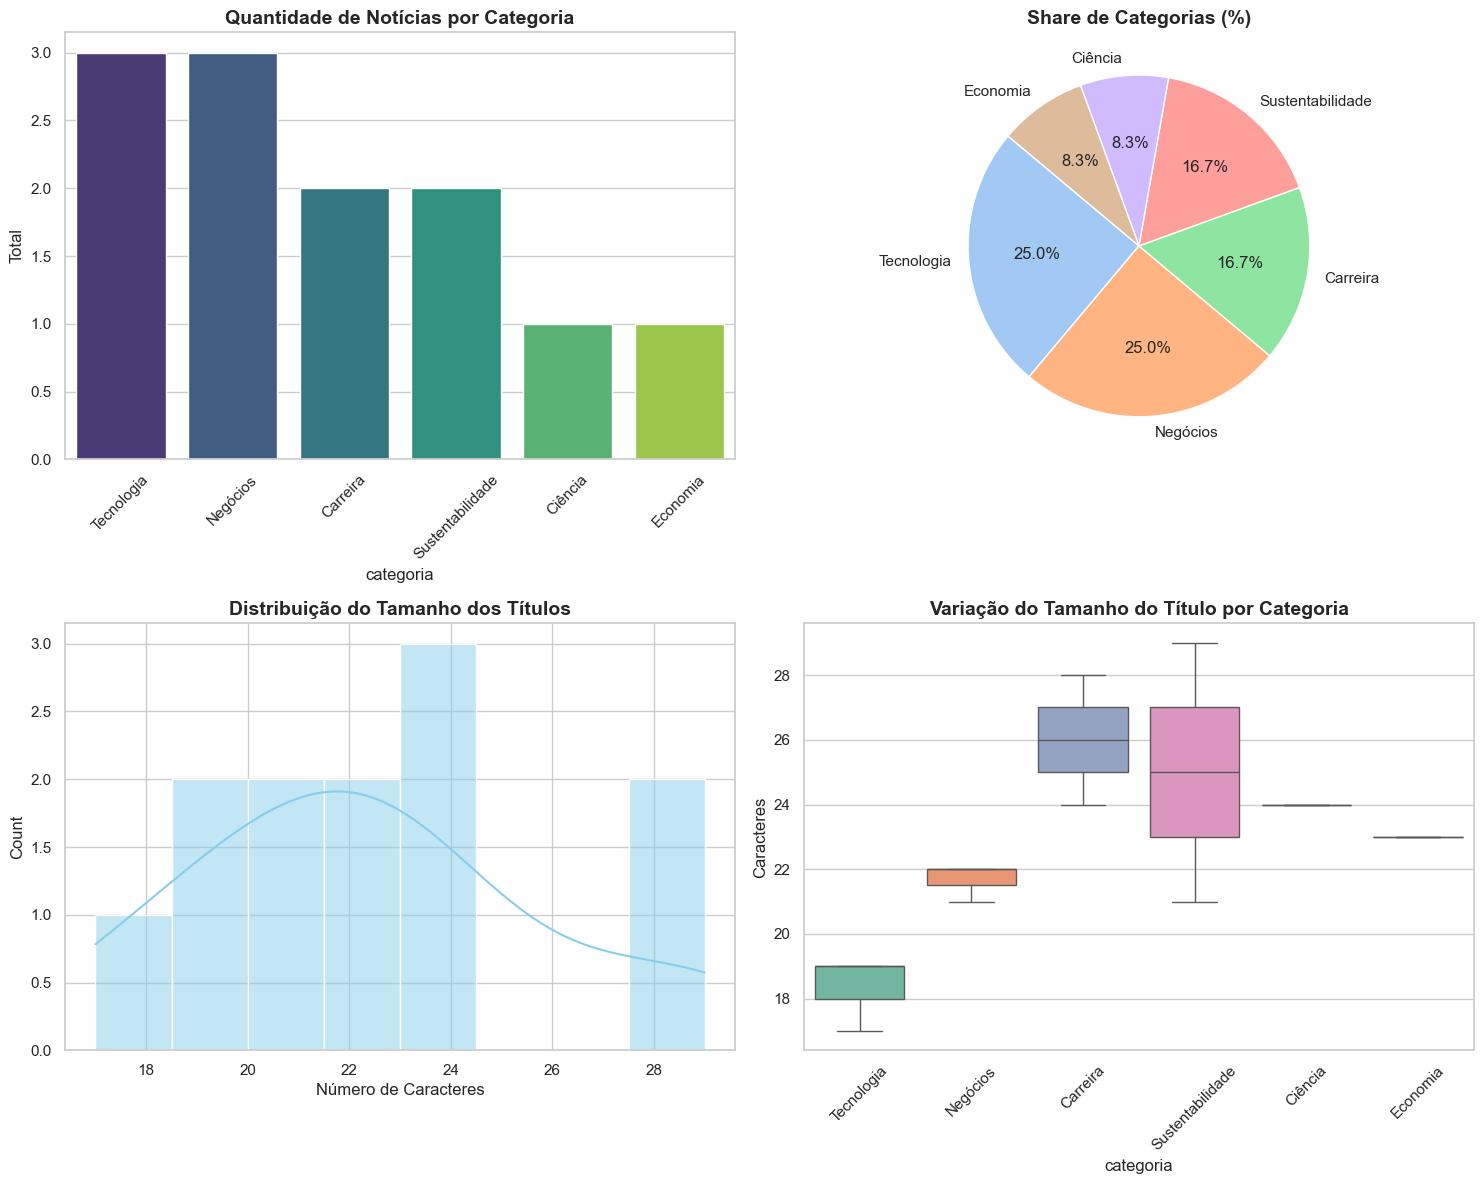

In [25]:
# Configurar figura para múltiplos gráficos
plt.figure(figsize=(15, 12))

# 1. Distribuição por Categoria (Barras)
plt.subplot(2, 2, 1)
contagem = df['categoria'].value_counts()
sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")
plt.title('Quantidade de Notícias por Categoria', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total')

# 2. Distribuição Percentual (Pizza)
plt.subplot(2, 2, 2)
plt.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Share de Categorias (%)', fontsize=14, fontweight='bold')

# 3. Histograma de Comprimento dos Títulos
plt.subplot(2, 2, 3)
sns.histplot(df['tamanho_titulo'], bins=8, color="skyblue", kde=True)
plt.title('Distribuição do Tamanho dos Títulos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Caracteres')

# 4. Boxplot de Tamanho do Título por Categoria
plt.subplot(2, 2, 4)
sns.boxplot(x='categoria', y='tamanho_titulo', data=df, palette="Set2")
plt.title('Variação do Tamanho do Título por Categoria', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Caracteres')

plt.tight_layout()
plt.show()

C:\Users\luizz\AppData\Local\Temp\ipykernel_14056\2480539652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_titulo.values, y=media_titulo.index, palette="magma")


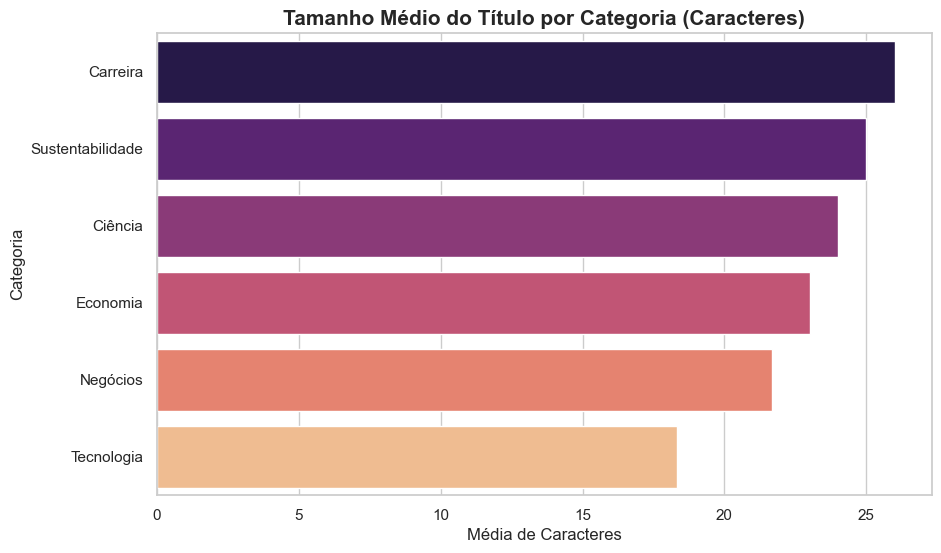

In [26]:
# 5. Análise de Médias: Tamanho Médio do Título por Categoria
plt.figure(figsize=(10, 6))
media_titulo = df.groupby('categoria')['tamanho_titulo'].mean().sort_values(ascending=False)

sns.barplot(x=media_titulo.values, y=media_titulo.index, palette="magma")

plt.title('Tamanho Médio do Título por Categoria (Caracteres)', fontsize=15, fontweight='bold')
plt.xlabel('Média de Caracteres')
plt.ylabel('Categoria')
plt.show()

--- 
## 5. Conclusão da Pipeline de Dados

Com as novas visualizações, podemos concluir que:
1. **Dominância de Temas**: Identificamos quais editorias possuem maior volume de publicações.
2. **Padrão de Escrita**: O histograma e o boxplot revelam se o portal mantém uma consistência no tamanho das manchetes ou se certas categorias (como 'Tecnologia') tendem a ter títulos mais longos ou curtos.
3. **Análise Comparativa**: O share percentual ajuda a entender o equilíbrio editorial do Nexus News.